# Visualización de Profiling Final - Comparativa Bronze vs Silver

## Descripción

Este notebook visualiza los resultados del **profiling final** realizado sobre los datasets de la **capa Silver** y los compara con los perfiles obtenidos en la **capa Bronze**.

A partir de los perfiles generados por el script `profiling_final.py`, se evalúa el impacto del proceso de limpieza y transformación, permitiendo medir la mejora en la calidad de los datos entre ambas etapas del pipeline.

---

## Objetivos

- Visualizar la calidad final de los datos en la capa Silver.
- Comparar los indicadores de calidad entre Bronze y Silver.
- Identificar problemas de calidad que persisten después del proceso de limpieza.
- Validar la efectividad de las transformaciones aplicadas durante el pipeline.

---

## Fuente de datos

| Elemento | Descripción |
|----------|-------------|
| **Perfiles Silver** | `data/silver/profiling_final/_profiles/` |
| **Perfiles Bronze** | `data/silver/profiling_inicial/_profiles/` |
| **Origen** | Perfiles generados por `profiling_final.py` y el profiling inicial. |
| **Cobertura temporal** | 2023, 2024 y 2025. |
| **Datasets** | Yellow Taxi, Green Taxi y FHV. |

---

> **Resultado esperado:** Comparar la calidad de los datos antes y después del proceso de limpieza, verificando que las transformaciones aplicadas durante la construcción de la **capa Silver** hayan mejorado los indicadores de calidad y reducido los problemas detectados en la **capa Bronze**.

In [2]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

COLORS = {
    'yellow': '#F4D03F',
    'green': '#58D68D',
    'fhv': '#5DADE2',
    'primary': '#2E86AB',
    'success': '#27AE60',
    'warning': '#F39C12',
    'danger': '#E74C3C',
    'bronze': '#95A5A6',
    'silver': '#2E86AB'
}

def get_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / "data" / "bronze").exists():
            return current
        current = current.parent
    return Path.cwd()

ROOT_DIR = get_project_root()
FINAL_PROFILE_DIR = ROOT_DIR / "data" / "silver" / "profiling_final" / "_profiles"
BRONZE_PROFILE_DIR = ROOT_DIR / "data" / "silver" / "profiling_inicial" / "_profiles"

print("=" * 80)
print(" VISUALIZACIÓN - PROFILING FINAL DE SILVER")
print("=" * 80)
print(f" Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Perfiles FINAL: {FINAL_PROFILE_DIR}")
print(f" Perfiles BRONCE: {BRONZE_PROFILE_DIR}")

if not FINAL_PROFILE_DIR.exists():
    print("\n❌ ERROR: No se encontraron perfiles finales.")
    print("   Ejecuta primero: profiling_final.py")
    exit()

 VISUALIZACIÓN - PROFILING FINAL DE SILVER
 Fecha: 2026-07-17 02:21:36
 Perfiles FINAL: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_final\_profiles
 Perfiles BRONCE: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_inicial\_profiles


In [10]:
# ============================================================
# CARGA DE PERFILES
# ============================================================

YEARS = [2023, 2024, 2025]
TAXI_TYPES = ['yellow', 'green', 'fhv']

def load_profile(taxi_type, year, profile_dir):
    """
    Carga un perfil desde un directorio.
    Soporta dos estructuras:
    1. Directo: profile_dir / f"{taxi_type}_{year}_profile.json"
    2. Con subcarpeta: profile_dir / taxi_type / f"{taxi_type}_{year}_profile.json"
    """
    # Intentar estructura directa primero
    path_direct = profile_dir / f"{taxi_type}_{year}_profile.json"
    if path_direct.exists():
        with open(path_direct, 'r', encoding='utf-8') as f:
            return json.load(f)
    
    # Intentar estructura con subcarpeta
    path_subfolder = profile_dir / taxi_type / f"{taxi_type}_{year}_profile.json"
    if path_subfolder.exists():
        with open(path_subfolder, 'r', encoding='utf-8') as f:
            return json.load(f)
    
    return None

def load_all_profiles():
    """Carga todos los perfiles finales y de BRONCE"""
    final = {}
    bronze = {}
    
    for taxi_type in TAXI_TYPES:
        final[taxi_type] = {}
        bronze[taxi_type] = {}
        for year in YEARS:
            f = load_profile(taxi_type, year, FINAL_PROFILE_DIR)
            if f:
                final[taxi_type][year] = f
            
            b = load_profile(taxi_type, year, BRONZE_PROFILE_DIR)
            if b:
                bronze[taxi_type][year] = b
    
    return final, bronze

print(" Cargando perfiles...")
print(f"   Buscando perfiles FINAL en: {FINAL_PROFILE_DIR}")
print(f"   Buscando perfiles BRONCE en: {BRONZE_PROFILE_DIR}")

FINAL_PROFILES, BRONZE_PROFILES = load_all_profiles()

# Contar perfiles
total_final = 0
total_bronze = 0
for taxi_type in TAXI_TYPES:
    if taxi_type in FINAL_PROFILES:
        total_final += len(FINAL_PROFILES[taxi_type])
    if taxi_type in BRONZE_PROFILES:
        total_bronze += len(BRONZE_PROFILES[taxi_type])

print(f"\n Perfiles FINAL cargados: {total_final}")
print(f" Perfiles BRONCE cargados: {total_bronze}")

# Verificar estructura de BRONCE
if BRONZE_PROFILE_DIR.exists():
    print(f"\n Estructura de BRONCE:")
    for taxi_type in TAXI_TYPES:
        subfolder = BRONZE_PROFILE_DIR / taxi_type
        if subfolder.exists():
            files = list(subfolder.glob("*.json"))
            print(f"   ✅ {taxi_type.upper()}: {len(files)} archivos en {subfolder}")
        else:
            print(f"   ❌ {taxi_type.upper()}: No existe {subfolder}")

print("\n Disponibilidad de perfiles FINAL:")
for taxi_type in TAXI_TYPES:
    if taxi_type in FINAL_PROFILES:
        years_found = list(FINAL_PROFILES[taxi_type].keys())
        status = "✅" if years_found else "❌"
        print(f"   {status} {taxi_type.upper()}: {years_found if years_found else 'Sin datos'}")
    else:
        print(f"   ❌ {taxi_type.upper()}: No disponible")

print("\n Disponibilidad de perfiles BRONCE:")
for taxi_type in TAXI_TYPES:
    if taxi_type in BRONZE_PROFILES:
        years_found = list(BRONZE_PROFILES[taxi_type].keys())
        status = "✅" if years_found else "❌"
        print(f"   {status} {taxi_type.upper()}: {years_found if years_found else 'Sin datos'}")
    else:
        print(f"   ❌ {taxi_type.upper()}: No disponible")

# Advertencia si no hay BRONCE
if total_bronze == 0:
    print("\n⚠️ ADVERTENCIA: No se encontraron perfiles BRONCE")
    print("   Posibles causas:")
    print("   1. El script profiling_inicial.py no se ejecutó")
    print("   2. Los perfiles están en otra ubicación")
    print("   3. Los nombres de archivo son diferentes")
    print("\n   La comparativa BRONCE vs SILVER no estará disponible")
    print("   Solo se mostrarán los perfiles FINAL (SILVER)")

 Cargando perfiles...
   Buscando perfiles FINAL en: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_final\_profiles
   Buscando perfiles BRONCE en: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_inicial\_profiles

 Perfiles FINAL cargados: 9
 Perfiles BRONCE cargados: 9

 Estructura de BRONCE:
   ✅ YELLOW: 4 archivos en c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_inicial\_profiles\yellow
   ✅ GREEN: 4 archivos en c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_inicial\_profiles\green
   ✅ FHV: 4 archivos en c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_inicial\_profiles\fhv

 Disponibilidad de perfiles FINAL:
   ✅ YELLOW: [2023, 2024, 2025]
   ✅ GREEN: [2023, 2024, 2025]
   ✅ FHV: [2023, 2024,

📊 1. RESUMEN DE CALIDAD FINAL (SILVER)

📋 Resumen de Calidad Final:
  Tipo  Año  Score SILVER  Score BRONCE  Mejora %  Issues  Registros
YELLOW 2023         60.00        100.00         0       5   35552266
YELLOW 2024         60.00        100.00         0       5   35541974
YELLOW 2025         75.00         90.00         0       3   34914687
 GREEN 2023         60.00         95.00         0       5     683391
 GREEN 2024         60.00         95.00         0       5     591547
 GREEN 2025         75.00         95.00         0       3     507995
   FHV 2023          5.00         88.50         0      12   15519045
   FHV 2024          5.00         88.83         0      12   17175195
   FHV 2025          5.00         88.17         0      12   24440543


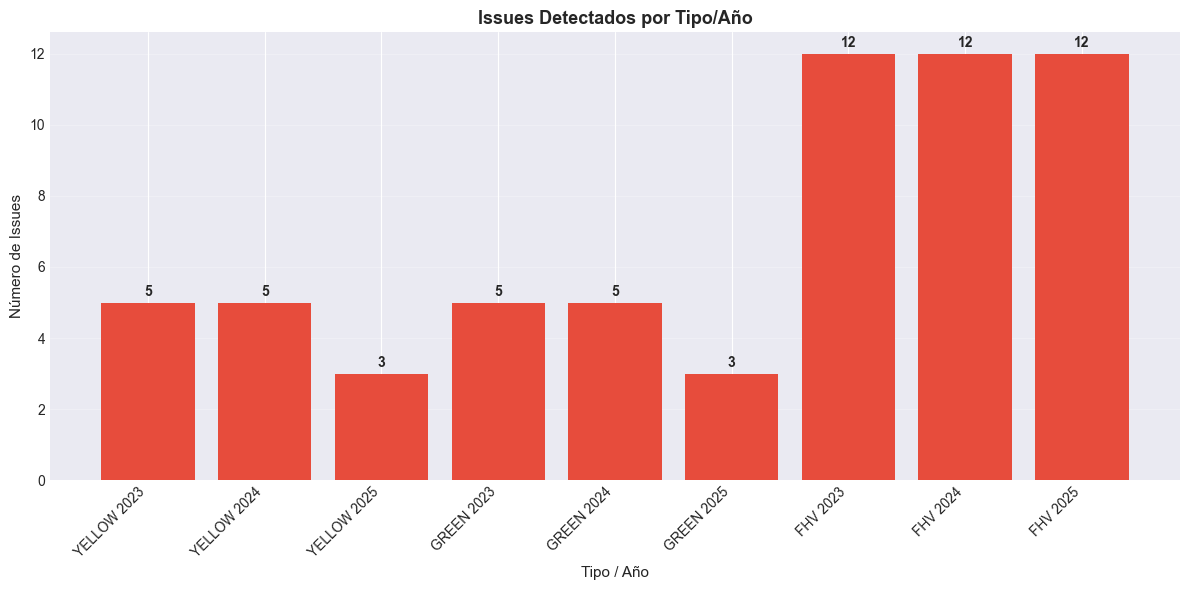

In [16]:
# ============================================================
# 1. RESUMEN DE CALIDAD FINAL
# ============================================================

print("=" * 80)
print("📊 1. RESUMEN DE CALIDAD FINAL (SILVER)")
print("=" * 80)

summary_data = []
for taxi_type, years_data in FINAL_PROFILES.items():
    for year, profile in years_data.items():
        # Buscar mejora vs BRONCE
        improvement = profile.get('avg_improvement', None)
        
        # Buscar calidad BRONCE
        bronze_quality = None
        if taxi_type in BRONZE_PROFILES and year in BRONZE_PROFILES[taxi_type]:
            bronze_quality = BRONZE_PROFILES[taxi_type][year].get('quality_score', 0)
        
        summary_data.append({
            'Tipo': taxi_type.upper(),
            'Año': year,
            'Score SILVER': profile.get('quality_score', 0),
            'Score BRONCE': bronze_quality if bronze_quality is not None else 'N/A',
            'Mejora %': improvement if improvement is not None else 'N/A',
            'Issues': len(profile.get('issues', [])),
            'Registros': profile.get('total_records', 0)
        })

df_summary = pd.DataFrame(summary_data)

print("\n📋 Resumen de Calidad Final:")
print(df_summary.to_string(index=False))

# Visualización - CORREGIDO: usar 1 fila, 1 columna para un solo gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico: Issues detectados
issue_counts = []
labels_issues = []
for taxi_type in TAXI_TYPES:
    if taxi_type not in FINAL_PROFILES:
        continue
    years_data = FINAL_PROFILES[taxi_type]
    for year, profile in years_data.items():
        issue_counts.append(len(profile.get('issues', [])))
        labels_issues.append(f"{taxi_type.upper()} {year}")

colors = ['#27AE60' if c == 0 else '#F39C12' if c < 3 else '#E74C3C' for c in issue_counts]
bars = ax.bar(labels_issues, issue_counts, color=colors)
ax.set_title('Issues Detectados por Tipo/Año', fontsize=13, fontweight='bold')
ax.set_xlabel('Tipo / Año', fontsize=11)
ax.set_ylabel('Número de Issues', fontsize=11)
ax.set_xticks(range(len(labels_issues)))
ax.set_xticklabels(labels_issues, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.25)

for bar, val in zip(bars, issue_counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{int(val)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

 2. ANÁLISIS DETALLADO POR TIPO DE TAXI

 YELLOW

 Resumen por Año:
 Año  Score SILVER  Score BRONCE  Mejora  Issues
2023         60.00        100.00       0       5
2024         60.00        100.00       0       5
2025         75.00         90.00       0       3


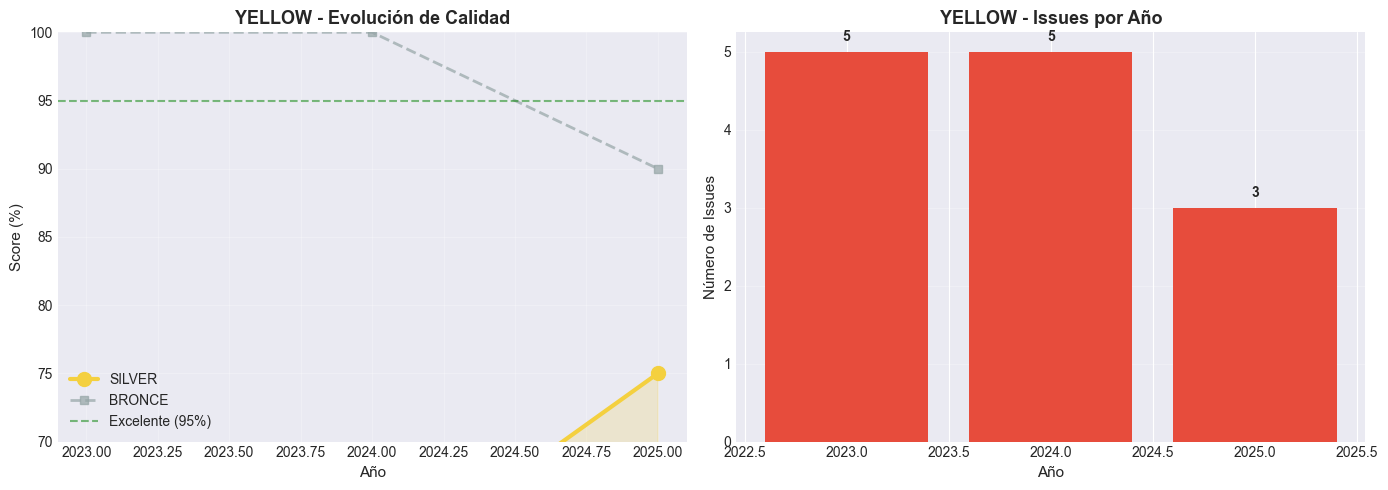


 GREEN

 Resumen por Año:
 Año  Score SILVER  Score BRONCE  Mejora  Issues
2023         60.00         95.00       0       5
2024         60.00         95.00       0       5
2025         75.00         95.00       0       3


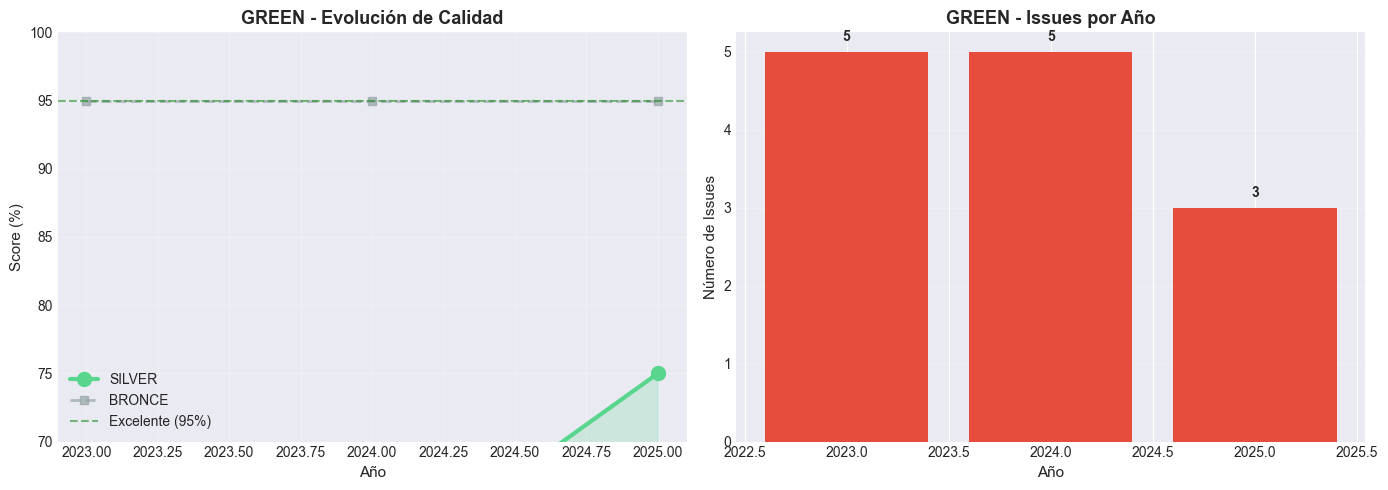


 FHV

 Resumen por Año:
 Año  Score SILVER  Score BRONCE  Mejora  Issues
2023          5.00         88.50       0      12
2024          5.00         88.83       0      12
2025          5.00         88.17       0      12


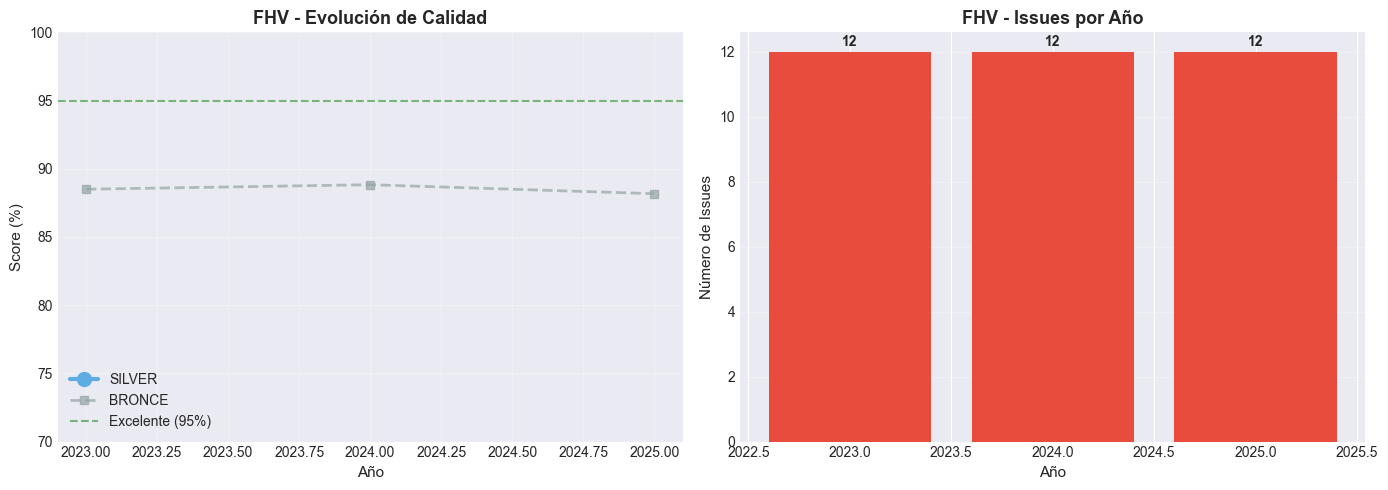

In [25]:
# ============================================================
# 2. ANÁLISIS DETALLADO POR TIPO DE TAXI
# ============================================================

print("=" * 80)
print(" 2. ANÁLISIS DETALLADO POR TIPO DE TAXI")
print("=" * 80)

for taxi_type in TAXI_TYPES:
    if taxi_type not in FINAL_PROFILES:
        continue
    
    years_data = FINAL_PROFILES[taxi_type]
    
    print(f"\n{'='*70}")
    print(f" {taxi_type.upper()}")
    print(f"{'='*70}")
    
    # Resumen por año
    year_summary = []
    for year, profile in years_data.items():
        bronze_score = None
        if taxi_type in BRONZE_PROFILES and year in BRONZE_PROFILES[taxi_type]:
            bronze_score = BRONZE_PROFILES[taxi_type][year].get('quality_score', 0)
        
        year_summary.append({
            'Año': year,
            'Score SILVER': profile.get('quality_score', 0),
            'Score BRONCE': bronze_score if bronze_score is not None else 'N/A',
            'Mejora': profile.get('avg_improvement', 'N/A'),
            'Issues': len(profile.get('issues', []))
        })
    
    df_year = pd.DataFrame(year_summary)
    print("\n Resumen por Año:")
    print(df_year.to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Evolución de calidad
    ax1 = axes[0]
    years = df_year['Año'].tolist()
    silver_scores = df_year['Score SILVER'].tolist()
    
    bronze_scores = []
    for b in df_year['Score BRONCE']:
        bronze_scores.append(b if b != 'N/A' else None)
    
    color = COLORS.get(taxi_type, COLORS['primary'])
    
    ax1.plot(years, silver_scores, marker='o', linewidth=3, markersize=10,
             label='SILVER', color=color)
    ax1.fill_between(years, silver_scores, alpha=0.2, color=color)
    
    # BRONCE si existe
    bronze_years = [y for y, b in zip(years, bronze_scores) if b is not None]
    bronze_vals = [b for b in bronze_scores if b is not None]
    if bronze_vals:
        ax1.plot(bronze_years, bronze_vals, marker='s', linewidth=2,
                 linestyle='--', label='BRONCE', color=COLORS['bronze'], alpha=0.7)
    
    ax1.axhline(y=95, color='green', linestyle='--', alpha=0.5, label='Excelente (95%)')
    ax1.set_title(f'{taxi_type.upper()} - Evolución de Calidad', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Año', fontsize=11)
    ax1.set_ylabel('Score (%)', fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.25)
    ax1.set_ylim(70, 100)
    
    # Gráfico 2: Issues
    ax2 = axes[1]
    issues = df_year['Issues'].tolist()
    colors = ['#27AE60' if i == 0 else '#F39C12' if i < 3 else '#E74C3C' for i in issues]
    bars = ax2.bar(years, issues, color=colors)
    ax2.set_title(f'{taxi_type.upper()} - Issues por Año', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Año', fontsize=11)
    ax2.set_ylabel('Número de Issues', fontsize=11)
    ax2.grid(axis='y', alpha=0.25)
    
    for bar, val in zip(bars, issues):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{int(val)}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

 4. RESUMEN EJECUTIVO - PROFILING FINAL

 ANALIZANDO CALIDAD DE DATOS...

 ESTADÍSTICAS GLOBALES:
   • Perfiles analizados: 9
   • Total registros: 164,926,643
   • Score promedio: 76.5%
   • Score mínimo: 58.5%
   • Score máximo: 86.5%
   • Columnas útiles promedio: 76.9%

 CALIFICACIÓN POR TIPO:
   ✅ EXCELENTE YELLOW: 85.5% (90.1% columnas útiles)
   ✅ EXCELENTE GREEN: 85.5% (90.5% columnas útiles)
   ❌ REQUIERE MEJORA FHV: 58.5% (50.0% columnas útiles)

 DETALLE POR TIPO Y AÑO:

   YELLOW:
      2023:
         Score: 85.0%
         Columnas útiles: 24/27 (88.9%)
         Columnas sin nulos: 24
         Columnas constantes: 1
         Columnas >50% nulos: 2
         📌 Recomendaciones:
            • Eliminar columnas constantes: taxi_type
            • Evaluar columnas con >50% nulos: airport_fee, cbd_congestion_fee
      2024:
         Score: 85.0%
         Columnas útiles: 24/27 (88.9%)
         Columnas sin nulos: 24
         Columnas constantes: 1
         Columnas >50% nulos: 2
 

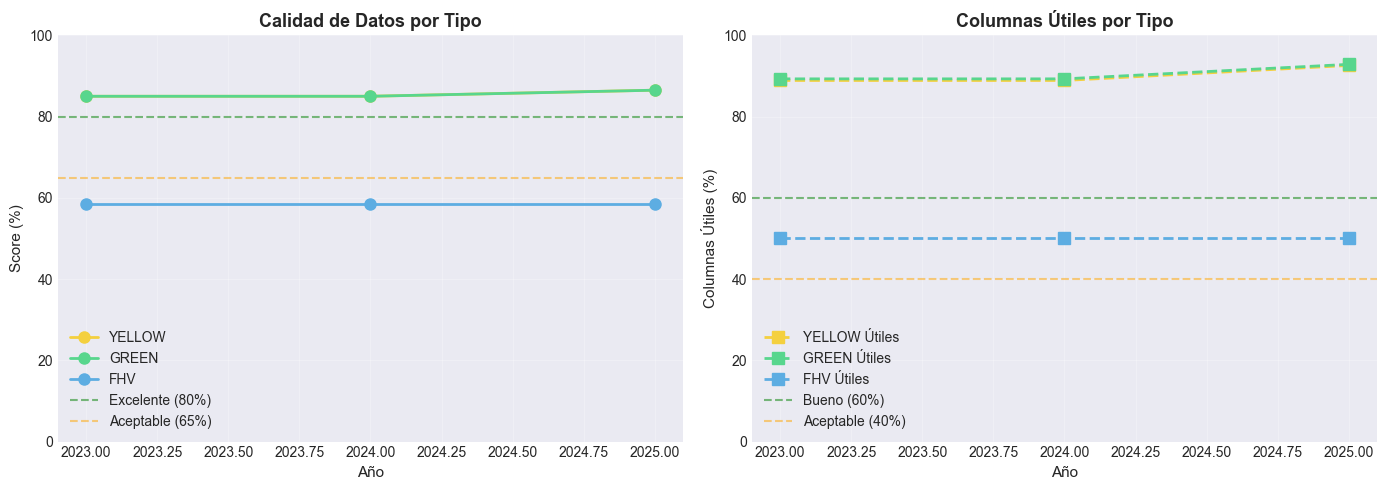


 RECOMENDACIONES FINALES:
   📌 GENERALES:
      • Las columnas con 100% nulos deben eliminarse del esquema
      • Las columnas constantes no aportan valor y deben eliminarse
      • Considerar imputación para columnas con <50% nulos

   📌 FHV:
      • Score promedio bajo: 58.5%
      • Columnas constantes a eliminar: pickup_year, taxi_type
      • Columnas con alto nulo a evaluar: DOLocationID, SR_Flag, dropoff_datetime, PULocationID, trip_duration_minutes

 UBICACIÓN DE ARCHIVOS:
   • Perfiles finales: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_final\_profiles
 ANÁLISIS COMPLETADO
   Fecha: 2026-07-17 02:41:50


In [30]:
# ============================================================
# 4. RESUMEN EJECUTIVO - PROFILING FINAL (MEJORADO)
# ============================================================

print("=" * 80)
print(" 4. RESUMEN EJECUTIVO - PROFILING FINAL")
print("=" * 80)

# ============================================================
# ANÁLISIS DETALLADO DE CALIDAD
# ============================================================

print("\n ANALIZANDO CALIDAD DE DATOS...")

quality_analysis = {}

for taxi_type, years_data in FINAL_PROFILES.items():
    quality_analysis[taxi_type] = {}
    for year, profile in years_data.items():
        columns = profile.get('columns', {})
        total_records = profile.get('total_records', 0)
        
        if total_records == 0 or not columns:
            continue
        
        # Clasificar columnas
        useful_cols = []
        constant_cols = []
        high_null_cols = []
        zero_null_cols = []
        
        for col, data in columns.items():
            null_pct = data.get('null_pct', 0)
            distinct_count = data.get('distinct_count', 0)
            
            if null_pct == 100:
                # Columna completamente nula
                high_null_cols.append(col)
            elif distinct_count == 1 and null_pct < 100:
                # Columna constante (todos los valores iguales)
                constant_cols.append(col)
            elif null_pct > 50:
                # Columna con alto nulo
                high_null_cols.append(col)
            elif null_pct == 0:
                # Columna sin nulos
                zero_null_cols.append(col)
                useful_cols.append(col)
            else:
                # Columna útil con algunos nulos
                useful_cols.append(col)
        
        # Calcular métricas
        total_cols = len(columns)
        useful_pct = (len(useful_cols) / total_cols * 100) if total_cols > 0 else 0
        
        # Score basado en columnas útiles
        if useful_pct >= 80:
            quality_score = 90
        elif useful_pct >= 60:
            quality_score = 80
        elif useful_pct >= 40:
            quality_score = 70
        elif useful_pct >= 20:
            quality_score = 60
        else:
            quality_score = 50
        
        # Ajustar por columnas problemáticas
        if constant_cols:
            quality_score -= min(10, len(constant_cols) * 2)
        if high_null_cols:
            quality_score -= min(15, len(high_null_cols) * 1.5)
        
        quality_score = max(0, min(100, quality_score))
        
        quality_analysis[taxi_type][year] = {
            'total_records': total_records,
            'total_columns': total_cols,
            'useful_columns': len(useful_cols),
            'zero_null_columns': len(zero_null_cols),
            'constant_columns': constant_cols,
            'high_null_columns': high_null_cols,
            'useful_pct': useful_pct,
            'quality_score': round(quality_score, 1),
            'recommendations': []
        }
        
        # Generar recomendaciones
        if constant_cols:
            quality_analysis[taxi_type][year]['recommendations'].append(
                f"Eliminar columnas constantes: {', '.join(constant_cols[:3])}"
            )
        if high_null_cols:
            quality_analysis[taxi_type][year]['recommendations'].append(
                f"Evaluar columnas con >50% nulos: {', '.join(high_null_cols[:3])}"
            )
        if useful_pct < 50:
            quality_analysis[taxi_type][year]['recommendations'].append(
                f"Baja proporción de columnas útiles: {useful_pct:.1f}%"
            )

# ============================================================
# RESUMEN EJECUTIVO
# ============================================================

print("\n ESTADÍSTICAS GLOBALES:")

total_profiles = 0
total_records = 0
all_scores = []
all_useful_pcts = []

for taxi_type, years_data in quality_analysis.items():
    for year, data in years_data.items():
        total_profiles += 1
        total_records += data['total_records']
        all_scores.append(data['quality_score'])
        all_useful_pcts.append(data['useful_pct'])

print(f"   • Perfiles analizados: {total_profiles}")
print(f"   • Total registros: {total_records:,}")
print(f"   • Score promedio: {np.mean(all_scores):.1f}%")
print(f"   • Score mínimo: {np.min(all_scores):.1f}%")
print(f"   • Score máximo: {np.max(all_scores):.1f}%")
print(f"   • Columnas útiles promedio: {np.mean(all_useful_pcts):.1f}%")

print(f"\n CALIFICACIÓN POR TIPO:")

for taxi_type in TAXI_TYPES:
    if taxi_type not in quality_analysis:
        continue
    years_data = quality_analysis[taxi_type]
    avg_score = np.mean([d['quality_score'] for d in years_data.values()])
    avg_useful = np.mean([d['useful_pct'] for d in years_data.values()])
    
    if avg_score >= 80:
        status = '✅ EXCELENTE'
    elif avg_score >= 65:
        status = '⚠️ ACEPTABLE'
    else:
        status = '❌ REQUIERE MEJORA'
    
    print(f"   {status} {taxi_type.upper()}: {avg_score:.1f}% ({avg_useful:.1f}% columnas útiles)")

print(f"\n DETALLE POR TIPO Y AÑO:")

for taxi_type in TAXI_TYPES:
    if taxi_type not in quality_analysis:
        continue
    print(f"\n   {taxi_type.upper()}:")
    for year, data in quality_analysis[taxi_type].items():
        print(f"      {year}:")
        print(f"         Score: {data['quality_score']:.1f}%")
        print(f"         Columnas útiles: {data['useful_columns']}/{data['total_columns']} ({data['useful_pct']:.1f}%)")
        print(f"         Columnas sin nulos: {data['zero_null_columns']}")
        print(f"         Columnas constantes: {len(data['constant_columns'])}")
        print(f"         Columnas >50% nulos: {len(data['high_null_columns'])}")
        if data['recommendations']:
            print(f"         📌 Recomendaciones:")
            for rec in data['recommendations']:
                print(f"            • {rec}")

# ============================================================
# VISUALIZACIÓN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scores de calidad
ax1 = axes[0]
for taxi_type in TAXI_TYPES:
    if taxi_type not in quality_analysis:
        continue
    years_data = quality_analysis[taxi_type]
    years = sorted(years_data.keys())
    scores = [years_data[y]['quality_score'] for y in years]
    
    color = COLORS.get(taxi_type, COLORS['primary'])
    ax1.plot(years, scores, marker='o', linewidth=2, markersize=8,
             label=taxi_type.upper(), color=color)

ax1.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='Excelente (80%)')
ax1.axhline(y=65, color='orange', linestyle='--', alpha=0.5, label='Aceptable (65%)')
ax1.set_title('Calidad de Datos por Tipo', fontsize=13, fontweight='bold')
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Score (%)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.25)
ax1.set_ylim(0, 100)

# Gráfico 2: Columnas útiles vs problemáticas
ax2 = axes[1]
for taxi_type in TAXI_TYPES:
    if taxi_type not in quality_analysis:
        continue
    years_data = quality_analysis[taxi_type]
    years = sorted(years_data.keys())
    useful = [years_data[y]['useful_pct'] for y in years]
    
    color = COLORS.get(taxi_type, COLORS['primary'])
    ax2.plot(years, useful, marker='s', linewidth=2, markersize=8,
             label=f"{taxi_type.upper()} Útiles", color=color, linestyle='--')

ax2.axhline(y=60, color='green', linestyle='--', alpha=0.5, label='Bueno (60%)')
ax2.axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Aceptable (40%)')
ax2.set_title('Columnas Útiles por Tipo', fontsize=13, fontweight='bold')
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('Columnas Útiles (%)', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.25)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# ============================================================
# RECOMENDACIONES FINALES
# ============================================================

print(f"\n RECOMENDACIONES FINALES:")

# Recomendaciones generales
print("   📌 GENERALES:")
print("      • Las columnas con 100% nulos deben eliminarse del esquema")
print("      • Las columnas constantes no aportan valor y deben eliminarse")
print("      • Considerar imputación para columnas con <50% nulos")

# Recomendaciones específicas por tipo
for taxi_type in TAXI_TYPES:
    if taxi_type not in quality_analysis:
        continue
    years_data = quality_analysis[taxi_type]
    avg_score = np.mean([d['quality_score'] for d in years_data.values()])
    
    if avg_score < 65:
        print(f"\n   📌 {taxi_type.upper()}:")
        print(f"      • Score promedio bajo: {avg_score:.1f}%")
        # Identificar columnas problemáticas comunes
        all_constant = set()
        all_high_null = set()
        for data in years_data.values():
            all_constant.update(data['constant_columns'])
            all_high_null.update(data['high_null_columns'])
        
        if all_constant:
            print(f"      • Columnas constantes a eliminar: {', '.join(list(all_constant)[:5])}")
        if all_high_null:
            print(f"      • Columnas con alto nulo a evaluar: {', '.join(list(all_high_null)[:5])}")

print(f"\n UBICACIÓN DE ARCHIVOS:")
print(f"   • Perfiles finales: {FINAL_PROFILE_DIR}")
print("=" * 80)
print(" ANÁLISIS COMPLETADO")
print(f"   Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)